# GPT-5.4 VLM 이미지 분석 노트북

이 노트북은 기존 OpenCV 기반 실험과 분리해서 `GPT-5.4` 비전 모델로 이미지를 분석하기 위한 별도 실험 환경이다.

주요 목표:
- 로컬 파일 또는 URL 이미지를 불러오기
- 이미지와 텍스트 프롬프트를 함께 GPT-5.4에 전달하기
- 응답을 JSON으로 파싱하고 저장하기
- 방 정보 같은 구조화 결과를 표와 시각화로 확인하기
- 폴더 단위 배치 분석으로 확장하기

기본 예시는 `data/original1.png`를 사용하며, 결과 파일은 `data/` 아래에 저장한다.

## 1. 환경 설정 및 패키지 준비

필요한 패키지를 확인하고 import한다. Azure OpenAI 설정은 `notebook/.env`에서 로드한다.

필수 환경 변수:
- `AZURE_OPENAI_ENDPOINT`
- `AZURE_OPENAI_DEPLOYMENT`

인증 방식:
- API 키 대신 `DefaultAzureCredential` 사용
- 로컬 개발 환경에서는 보통 `az login` 또는 VS Code/Azure 로그인 상태를 사용
- Azure 배포 환경에서는 관리형 ID를 사용할 수 있다

처음 실행하는 환경이면 아래 설치 셀을 먼저 실행한다.

In [42]:
# %pip install -q openai pillow matplotlib pandas requests python-dotenv azure-identity

In [43]:
import base64
import json
import logging
import mimetypes
import os
import re
import time
from datetime import datetime
from io import BytesIO
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import requests
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from dotenv import load_dotenv
from IPython.display import display
from openai import OpenAI
from PIL import Image, ImageDraw

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")
logger = logging.getLogger("gpt54-vlm")

WORKSPACE_ROOT = Path.cwd().resolve()
if not (WORKSPACE_ROOT / "data").exists() and (WORKSPACE_ROOT.parent / "data").exists():
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent.resolve()

NOTEBOOK_DIR = WORKSPACE_ROOT / "notebook"
ENV_PATH = NOTEBOOK_DIR / ".env"
load_dotenv(ENV_PATH, override=False)

DATA_DIR = WORKSPACE_ROOT / "data"
OUTPUT_DIR = DATA_DIR / "vlm_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AZURE_OPENAI_ENDPOINT = os.environ.get("AZURE_OPENAI_ENDPOINT")
AZURE_OPENAI_DEPLOYMENT = os.environ.get("AZURE_OPENAI_DEPLOYMENT", "gpt-5.4")
MODEL_NAME = AZURE_OPENAI_DEPLOYMENT
DEFAULT_IMAGE_SOURCE = str(DATA_DIR / "original1.png")

print(f"Workspace root: {WORKSPACE_ROOT}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Loaded env file: {ENV_PATH} -> {ENV_PATH.exists()}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Default image source: {DEFAULT_IMAGE_SOURCE}")
print(f"AZURE_OPENAI_ENDPOINT configured: {bool(AZURE_OPENAI_ENDPOINT)}")
print(f"AZURE_OPENAI_DEPLOYMENT: {AZURE_OPENAI_DEPLOYMENT}")
print("Authentication mode: DefaultAzureCredential")

if not AZURE_OPENAI_ENDPOINT:
    raise EnvironmentError("AZURE_OPENAI_ENDPOINT 환경 변수가 필요합니다.")
if not AZURE_OPENAI_DEPLOYMENT:
    raise EnvironmentError("AZURE_OPENAI_DEPLOYMENT 환경 변수가 필요합니다.")

Workspace root: /Users/andy/works/ai/maf-boilerplate
Notebook directory: /Users/andy/works/ai/maf-boilerplate/notebook
Loaded env file: /Users/andy/works/ai/maf-boilerplate/notebook/.env -> True
Data directory: /Users/andy/works/ai/maf-boilerplate/data
Output directory: /Users/andy/works/ai/maf-boilerplate/data/vlm_outputs
Default image source: /Users/andy/works/ai/maf-boilerplate/data/original1.png
AZURE_OPENAI_ENDPOINT configured: True
AZURE_OPENAI_DEPLOYMENT: gpt-5.4
Authentication mode: DefaultAzureCredential


## 2. 이미지 입력 경로 및 샘플 데이터 로드

분석 대상 이미지와 one-shot 예시 이미지를 함께 로드한다.

- `original2.png`: 예시 입력 원본
- `target2.png`: 예시 입력에 대한 기대 결과 이미지
- `original1.png`: 실제 방 추출 대상

Target source: /Users/andy/works/ai/maf-boilerplate/data/original1.png
One-shot input source: /Users/andy/works/ai/maf-boilerplate/data/original2.png
One-shot target source: /Users/andy/works/ai/maf-boilerplate/data/target2.png
Target image size: (905, 475)


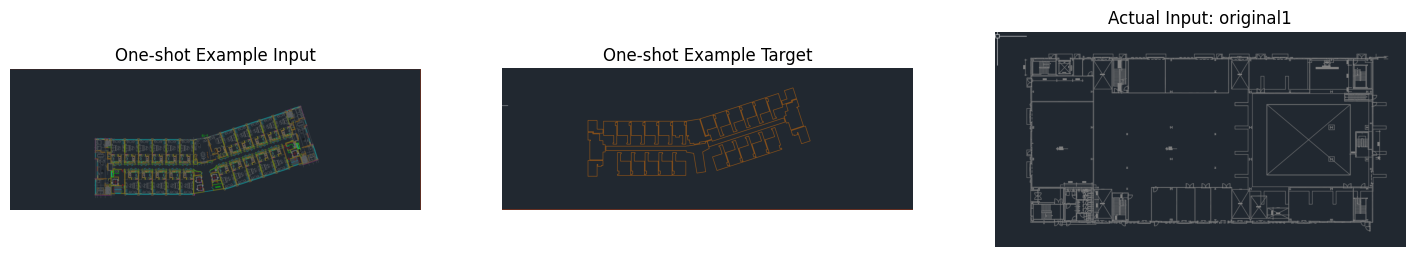

{'srgb': 0, 'gamma': 0.45455, 'dpi': (95.9866, 95.9866)}


In [44]:
IMAGE_SOURCE = DEFAULT_IMAGE_SOURCE
ONESHOT_INPUT_SOURCE = str(DATA_DIR / "original2.png")
ONESHOT_TARGET_SOURCE = str(DATA_DIR / "target2.png")


def is_url(source: str) -> bool:
    return source.startswith("http://") or source.startswith("https://")



def resolve_image_source(source: str) -> tuple[str, bytes, Image.Image]:
    if is_url(source):
        response = requests.get(source, timeout=30)
        response.raise_for_status()
        image_bytes = response.content
        image = Image.open(BytesIO(image_bytes)).convert("RGB")
        return source, image_bytes, image

    path = Path(source)
    if not path.is_absolute():
        path = (WORKSPACE_ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {path}")

    image_bytes = path.read_bytes()
    image = Image.open(BytesIO(image_bytes)).convert("RGB")
    return str(path), image_bytes, image


resolved_source, image_bytes, pil_image = resolve_image_source(IMAGE_SOURCE)
example_input_source, example_input_bytes, example_input_image = resolve_image_source(ONESHOT_INPUT_SOURCE)
example_target_source, example_target_bytes, example_target_image = resolve_image_source(ONESHOT_TARGET_SOURCE)

print(f"Target source: {resolved_source}")
print(f"One-shot input source: {example_input_source}")
print(f"One-shot target source: {example_target_source}")
print(f"Target image size: {pil_image.size}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(example_input_image)
axes[0].set_title("One-shot Example Input")
axes[0].axis("off")

axes[1].imshow(example_target_image)
axes[1].set_title("One-shot Example Target")
axes[1].axis("off")

axes[2].imshow(pil_image)
axes[2].set_title("Actual Input: original1")
axes[2].axis("off")
plt.show()

print(getattr(pil_image, "info", {}))

## 3. GPT-5.4 VLM 클라이언트 초기화

Azure OpenAI endpoint와 deployment를 사용하도록 클라이언트를 초기화한다. 인증은 `DefaultAzureCredential` 기반 bearer token provider를 사용한다.

In [45]:
AZURE_OPENAI_BASE_URL = f"{AZURE_OPENAI_ENDPOINT.rstrip('/')}/openai/v1/"
AZURE_COGNITIVE_SCOPE = "https://cognitiveservices.azure.com/.default"

credential = DefaultAzureCredential()
token_provider = get_bearer_token_provider(credential, AZURE_COGNITIVE_SCOPE)

client = OpenAI(
    api_key=token_provider,
    base_url=AZURE_OPENAI_BASE_URL,
)

DEFAULT_REQUEST_OPTIONS = {
    "model": MODEL_NAME,
    "reasoning": {"effort": "high"},
}



def timestamp_slug() -> str:
    return datetime.now().strftime("%Y%m%d_%H%M%S")



def next_output_path(prefix: str, suffix: str) -> Path:
    return OUTPUT_DIR / f"{prefix}_{timestamp_slug()}{suffix}"



def image_bytes_to_data_url(source: str, payload: bytes) -> str:
    mime_type, _ = mimetypes.guess_type(source)
    mime_type = mime_type or "image/png"
    encoded = base64.b64encode(payload).decode("utf-8")
    return f"data:{mime_type};base64,{encoded}"


print(
    {
        **DEFAULT_REQUEST_OPTIONS,
        "base_url": AZURE_OPENAI_BASE_URL,
        "auth": "DefaultAzureCredential",
        "reasoning_note": "gpt-5.4 does not support xhigh; using the highest supported effort: high",
    }
)

[INFO] No environment configuration found.
[INFO] ManagedIdentityCredential will use IMDS


{'model': 'gpt-5.4', 'reasoning': {'effort': 'high'}, 'base_url': 'https://admin-me7tpdlm-eastus2.services.ai.azure.com/openai/v1/', 'auth': 'DefaultAzureCredential', 'reasoning_note': 'gpt-5.4 does not support xhigh; using the highest supported effort: high'}


## 4. one-shot 이미지 분석 프롬프트 구성

`original2 -> target2` 예시 쌍을 먼저 보여준 뒤, 같은 패턴으로 `original1`의 방을 추출하도록 프롬프트를 구성한다.

In [46]:
ROOM_SCHEMA = {
    "image_source": "string",
    "analysis_type": "room_extraction",
    "summary": "string",
    "rooms": [
        {
            "id": "string",
            "label": "string",
            "confidence": "float between 0 and 1",
            "bbox": {
                "x": "integer pixel",
                "y": "integer pixel",
                "width": "integer pixel",
                "height": "integer pixel"
            },
            "notes": "string"
        }
    ],
    "warnings": ["string"]
}

SYSTEM_PROMPT = """
You are a vision model that analyzes floor-plan images precisely.
Return JSON only.
Do not wrap the JSON in markdown fences.
If a field is unknown, use null or an empty list.
Bounding boxes must be in absolute pixel coordinates relative to the original image.
Learn the room extraction style from the one-shot example pair and apply the same behavior to the target image.
When a large enclosed area is visibly divided into separate rooms by an interior wall or doorway structure, split it into multiple rooms instead of merging it.
Treat narrow but enclosed side spaces as valid rooms when they are bounded by walls, even if they are smaller than adjacent rooms.
""".strip()

PROMPT_TEMPLATES = {
    "room_extraction": """
You will receive three images in order:
1. one-shot example input image
2. one-shot example target image showing the desired room-extraction style
3. target image to analyze

Your task is to infer the extraction style from images 1 and 2, then produce structured room extraction JSON for image 3.
Return JSON matching this schema exactly:
{schema}

Rules:
- Treat each clearly separated room as one item in rooms.
- Prefer concise labels such as room_1, room_2 when semantic room type is uncertain.
- Estimate bounding boxes conservatively around the visible room area in the target image.
- confidence must be between 0 and 1.
- summary should briefly describe the extraction result.
- warnings should mention ambiguity, weak walls, or low confidence regions.
- Use the one-shot example target as the visual reference for what counts as a detected room.
- Do not merge rooms that are visibly separated by an internal partition, even if they were previously grouped under one label.
- For the target image `original1.png`, apply these corrections explicitly:
  - The area currently perceived as room_1 should be split into two separate rooms.
  - The enclosed area immediately to the left of room_3 must also be counted as an additional room.
- If the model is uncertain, prefer over-separating enclosed spaces rather than collapsing adjacent rooms into one.
""".strip(),
    "scene_description": """
Describe the image scene in structured JSON.
Return JSON with keys: image_source, analysis_type, summary, objects, warnings.
""".strip(),
    "table_extraction": """
Extract any visible table-like structure.
Return JSON with keys: image_source, analysis_type, summary, columns, rows, warnings.
""".strip(),
}

SELECTED_ANALYSIS_TYPE = "room_extraction"
USER_PROMPT = PROMPT_TEMPLATES[SELECTED_ANALYSIS_TYPE].format(
    schema=json.dumps(ROOM_SCHEMA, indent=2, ensure_ascii=False)
)

print(USER_PROMPT[:2200])

You will receive three images in order:
1. one-shot example input image
2. one-shot example target image showing the desired room-extraction style
3. target image to analyze

Your task is to infer the extraction style from images 1 and 2, then produce structured room extraction JSON for image 3.
Return JSON matching this schema exactly:
{
  "image_source": "string",
  "analysis_type": "room_extraction",
  "summary": "string",
  "rooms": [
    {
      "id": "string",
      "label": "string",
      "confidence": "float between 0 and 1",
      "bbox": {
        "x": "integer pixel",
        "y": "integer pixel",
        "width": "integer pixel",
        "height": "integer pixel"
      },
      "notes": "string"
    }
  ],
  "warnings": [
    "string"
  ]
}

Rules:
- Treat each clearly separated room as one item in rooms.
- Prefer concise labels such as room_1, room_2 when semantic room type is uncertain.
- Estimate bounding boxes conservatively around the visible room area in the target i

## 5. one-shot 예시와 실제 이미지를 함께 전달해 분석 실행

`original2`와 `target2`를 one-shot 예시로 먼저 전달하고, 같은 규칙으로 `original1`의 방을 추출한다.

In [47]:
def response_to_dict(response: Any) -> dict[str, Any]:
    if hasattr(response, "model_dump"):
        return response.model_dump()
    if hasattr(response, "to_dict"):
        return response.to_dict()
    return {"raw": str(response)}



def build_multimodal_content(label: str, source: str) -> list[dict[str, Any]]:
    resolved, payload, _ = resolve_image_source(source)
    data_url = image_bytes_to_data_url(resolved, payload)
    return [
        {"type": "input_text", "text": label},
        {"type": "input_image", "image_url": data_url},
    ]



def call_gpt54_vision(
    image_source: str,
    prompt: str,
    system_prompt: str = SYSTEM_PROMPT,
    oneshot_input_source: str | None = ONESHOT_INPUT_SOURCE,
    oneshot_target_source: str | None = ONESHOT_TARGET_SOURCE,
    **overrides: Any,
) -> Any:
    request_options = {**DEFAULT_REQUEST_OPTIONS, **overrides}
    user_content: list[dict[str, Any]] = [{"type": "input_text", "text": prompt}]

    if oneshot_input_source:
        user_content.extend(build_multimodal_content("Image 1: one-shot example input.", oneshot_input_source))
    if oneshot_target_source:
        user_content.extend(build_multimodal_content("Image 2: one-shot example target output image.", oneshot_target_source))
    user_content.extend(build_multimodal_content("Image 3: actual target image to analyze.", image_source))

    response_kwargs = {
        "model": request_options["model"],
        "input": [
            {
                "role": "system",
                "content": [{"type": "input_text", "text": system_prompt}],
            },
            {
                "role": "user",
                "content": user_content,
            },
        ],
    }
    if request_options.get("reasoning"):
        response_kwargs["reasoning"] = request_options["reasoning"]

    return client.responses.create(**response_kwargs)


raw_response = call_gpt54_vision(IMAGE_SOURCE, USER_PROMPT)
raw_response_text = getattr(raw_response, "output_text", "")
raw_response_payload = response_to_dict(raw_response)
raw_output_path = next_output_path("single_raw_response_oneshot", ".json")
raw_output_path.write_text(json.dumps(raw_response_payload, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Raw response saved to: {raw_output_path}")
print(raw_response_text[:2000])

[INFO] Request URL: 'http://169.254.169.254/metadata/identity/oauth2/token?api-version=REDACTED&resource=REDACTED'
Request method: 'GET'
Request headers:
    'User-Agent': 'azsdk-python-identity/1.25.3 Python/3.12.13 (macOS-26.4.1-arm64-arm-64bit)'
No body was attached to the request
[INFO] DefaultAzureCredential acquired a token from AzureCliCredential
[INFO] HTTP Request: POST https://admin-me7tpdlm-eastus2.services.ai.azure.com/openai/v1/responses "HTTP/1.1 200 OK"


Raw response saved to: /Users/andy/works/ai/maf-boilerplate/data/vlm_outputs/single_raw_response_oneshot_20260421_115607.json
{
  "image_source": "original1.png",
  "analysis_type": "room_extraction",
  "summary": "Extracted 26 enclosed spaces from the floor plan, including a split of the top-center band into two rooms and a narrow enclosed room immediately left of the atrium-side block; open circulation and the central atrium were excluded.",
  "rooms": [
    {
      "id": "room_1",
      "label": "room_1",
      "confidence": 0.64,
      "bbox": {
        "x": 78,
        "y": 58,
        "width": 38,
        "height": 60
      },
      "notes": "Top-left enclosed service/core space."
    },
    {
      "id": "room_2",
      "label": "room_2",
      "confidence": 0.6,
      "bbox": {
        "x": 116,
        "y": 50,
        "width": 54,
        "height": 68
      },
      "notes": "Top-left enclosed core compartment."
    },
    {
      "id": "room_3",
      "label": "room_3",
    

## 6. 응답 파싱 및 구조화된 결과 저장

모델 응답에서 JSON을 안전하게 추출하고, 후속 분석을 위해 JSON과 DataFrame 형태로 저장한다.

In [48]:
def extract_json_block(text: str) -> Any:
    text = text.strip()
    if not text:
        raise ValueError("응답 텍스트가 비어 있습니다.")

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    fenced = re.search(r"```json\s*(.*?)\s*```", text, flags=re.DOTALL | re.IGNORECASE)
    if fenced:
        return json.loads(fenced.group(1))

    object_match = re.search(r"(\{.*\})", text, flags=re.DOTALL)
    if object_match:
        return json.loads(object_match.group(1))

    array_match = re.search(r"(\[.*\])", text, flags=re.DOTALL)
    if array_match:
        return json.loads(array_match.group(1))

    raise ValueError("응답에서 JSON을 추출하지 못했습니다.")



def normalize_rooms(parsed: dict[str, Any]) -> pd.DataFrame:
    rooms = parsed.get("rooms", []) or []
    normalized = []
    for room in rooms:
        bbox = room.get("bbox") or {}
        normalized.append(
            {
                "id": room.get("id"),
                "label": room.get("label"),
                "confidence": room.get("confidence"),
                "x": bbox.get("x"),
                "y": bbox.get("y"),
                "width": bbox.get("width"),
                "height": bbox.get("height"),
                "notes": room.get("notes"),
            }
        )
    return pd.DataFrame(normalized)


parsed_result = extract_json_block(raw_response_text)
parsed_result.setdefault("image_source", resolved_source)
parsed_result.setdefault("analysis_type", SELECTED_ANALYSIS_TYPE)
parsed_result.setdefault("one_shot_example", {
    "input": example_input_source,
    "target": example_target_source,
})

parsed_output_path = next_output_path("single_parsed_result_oneshot", ".json")
parsed_output_path.write_text(json.dumps(parsed_result, indent=2, ensure_ascii=False), encoding="utf-8")

rooms_df = normalize_rooms(parsed_result)
csv_output_path = next_output_path("single_rooms_oneshot", ".csv")
rooms_df.to_csv(csv_output_path, index=False)

print(f"Parsed JSON saved to: {parsed_output_path}")
print(f"Tabular CSV saved to: {csv_output_path}")
display(rooms_df)
parsed_result

Parsed JSON saved to: /Users/andy/works/ai/maf-boilerplate/data/vlm_outputs/single_parsed_result_oneshot_20260421_115607.json
Tabular CSV saved to: /Users/andy/works/ai/maf-boilerplate/data/vlm_outputs/single_rooms_oneshot_20260421_115607.csv


,id,label,confidence,x,y,width,height,notes
0,room_1,room_1,0.64,78,58,38,60,Top-left enclosed service/core space.
1,room_2,room_2,0.60,116,50,54,68,Top-left enclosed core compartment.
2,room_3,room_3,0.57,171,50,43,68,Top-left narrow enclosed room/core area.
3,room_4,room_4,0.94,79,118,136,226,Large enclosed room on the left side.
4,room_5,room_5,0.72,79,346,34,76,Bottom-left small enclosed room.
5,room_6,room_6,0.70,113,346,102,76,Bottom-left enclosed service/toilet cluster tr...
6,room_7,room_7,0.66,215,347,45,75,Bottom-left enclosed stair/core room.
7,room_8,room_8,0.86,259,58,115,78,Top-center left room; split from the adjacent ...
8,room_9,room_9,0.86,374,58,145,78,Top-center right room; separate from room_8 by...
9,room_10,room_10,0.96,216,136,343,208,Large central enclosed room.


{'image_source': 'original1.png',
 'analysis_type': 'room_extraction',
 'summary': 'Extracted 26 enclosed spaces from the floor plan, including a split of the top-center band into two rooms and a narrow enclosed room immediately left of the atrium-side block; open circulation and the central atrium were excluded.',
 'rooms': [{'id': 'room_1',
   'label': 'room_1',
   'confidence': 0.64,
   'bbox': {'x': 78, 'y': 58, 'width': 38, 'height': 60},
   'notes': 'Top-left enclosed service/core space.'},
  {'id': 'room_2',
   'label': 'room_2',
   'confidence': 0.6,
   'bbox': {'x': 116, 'y': 50, 'width': 54, 'height': 68},
   'notes': 'Top-left enclosed core compartment.'},
  {'id': 'room_3',
   'label': 'room_3',
   'confidence': 0.57,
   'bbox': {'x': 171, 'y': 50, 'width': 43, 'height': 68},
   'notes': 'Top-left narrow enclosed room/core area.'},
  {'id': 'room_4',
   'label': 'room_4',
   'confidence': 0.94,
   'bbox': {'x': 79, 'y': 118, 'width': 136, 'height': 226},
   'notes': 'Large 

## 7. 여러 이미지 일괄 분석 함수 작성

폴더 내 이미지를 순회하며 GPT-5.4 분석을 수행하고 결과를 누적 저장하는 함수를 정의한다.

In [49]:
def list_image_files(folder: str | Path) -> list[Path]:
    folder_path = Path(folder)
    if not folder_path.is_absolute():
        folder_path = (WORKSPACE_ROOT / folder_path).resolve()
    patterns = ["*.png", "*.jpg", "*.jpeg", "*.webp"]
    files = []
    for pattern in patterns:
        files.extend(folder_path.glob(pattern))
    return sorted(set(files))



def analyze_single_image(image_source: str, analysis_type: str = "room_extraction") -> dict[str, Any]:
    prompt = PROMPT_TEMPLATES[analysis_type].format(
        schema=json.dumps(ROOM_SCHEMA, indent=2, ensure_ascii=False)
    )
    response = call_gpt54_vision(
        image_source,
        prompt,
        oneshot_input_source=ONESHOT_INPUT_SOURCE,
        oneshot_target_source=ONESHOT_TARGET_SOURCE,
    )
    text = getattr(response, "output_text", "")
    parsed = extract_json_block(text)
    parsed.setdefault("image_source", image_source)
    parsed.setdefault("analysis_type", analysis_type)
    return {
        "parsed": parsed,
        "raw_payload": response_to_dict(response),
        "raw_text": text,
    }



def batch_analyze_images(folder: str | Path, analysis_type: str = "room_extraction") -> pd.DataFrame:
    images = list_image_files(folder)
    if not images:
        raise FileNotFoundError(f"분석할 이미지가 없습니다: {folder}")

    records = []
    batch_json_path = next_output_path("batch_results_oneshot", ".json")
    batch_payload = []

    for index, image_path in enumerate(images, start=1):
        if image_path.name in {Path(ONESHOT_INPUT_SOURCE).name, Path(ONESHOT_TARGET_SOURCE).name}:
            continue
        logger.info("[%s/%s] analyzing %s", index, len(images), image_path.name)
        result = analyze_single_image(str(image_path), analysis_type=analysis_type)
        parsed = result["parsed"]
        batch_payload.append(parsed)

        room_count = len(parsed.get("rooms", []) or [])
        records.append(
            {
                "image_source": str(image_path),
                "analysis_type": parsed.get("analysis_type"),
                "summary": parsed.get("summary"),
                "room_count": room_count,
                "warnings": " | ".join(parsed.get("warnings", []) or []),
            }
        )

    batch_json_path.write_text(json.dumps(batch_payload, indent=2, ensure_ascii=False), encoding="utf-8")
    batch_df = pd.DataFrame(records)
    batch_csv_path = next_output_path("batch_summary_oneshot", ".csv")
    batch_df.to_csv(batch_csv_path, index=False)
    print(f"Batch JSON saved to: {batch_json_path}")
    print(f"Batch CSV saved to: {batch_csv_path}")
    return batch_df


# 예시
# batch_df = batch_analyze_images(DATA_DIR)
# display(batch_df.head())

## 8. 분석 결과를 표와 시각화로 확인

one-shot 예시를 기준으로 추출된 `original1`의 방 bounding box와 confidence를 시각화하고, 원본 이미지와 함께 비교한다.

,id,label,confidence,x,y,width,height,notes
9,room_10,room_10,0.96,216,136,343,208,Large central enclosed room.
3,room_4,room_4,0.94,79,118,136,226,Large enclosed room on the left side.
13,room_14,room_14,0.88,691,58,114,72,Top-right middle room.
12,room_13,room_13,0.88,560,58,131,72,Top-right left room.
7,room_8,room_8,0.86,259,58,115,78,Top-center left room; split from the adjacent ...
8,room_9,room_9,0.86,374,58,145,78,Top-center right room; separate from room_8 by...
17,room_18,room_18,0.83,408,344,63,78,Bottom-center middle room.
16,room_17,room_17,0.83,345,344,63,78,Bottom-center left room.
21,room_22,room_22,0.82,597,352,62,70,Bottom-right left room.
18,room_19,room_19,0.81,471,344,53,78,Bottom-center right room.


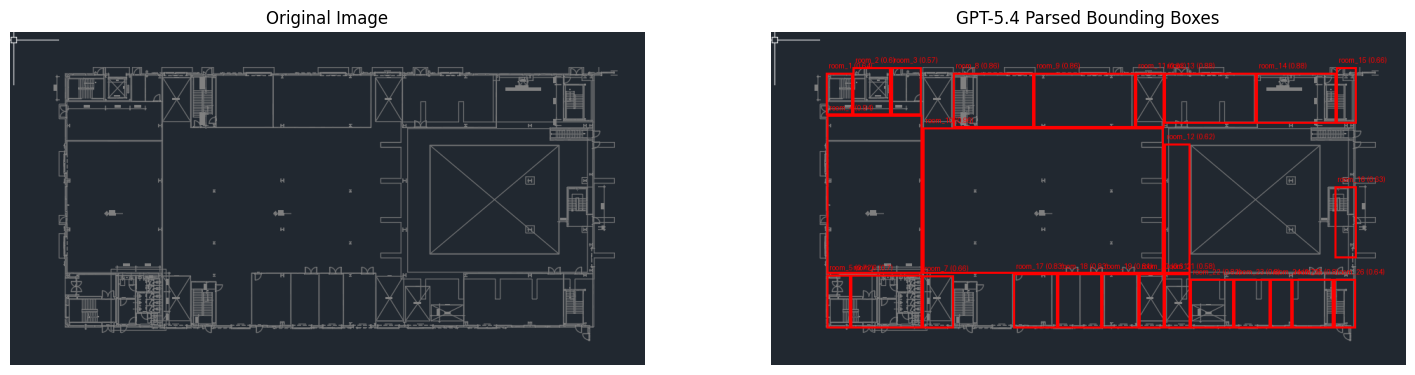

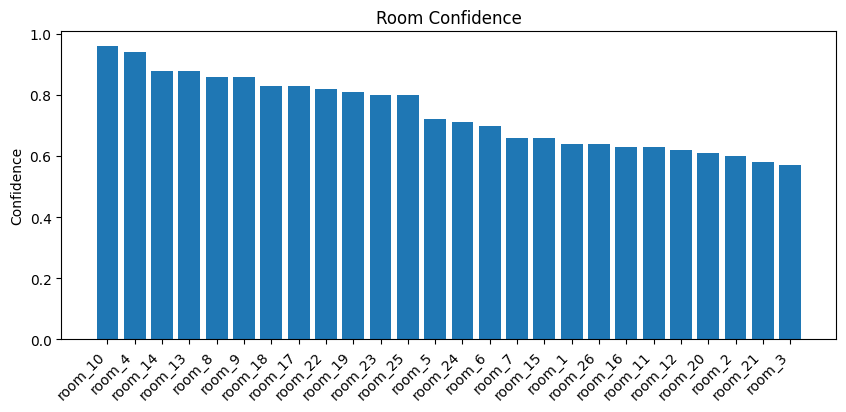

Annotated image saved to: /Users/andy/works/ai/maf-boilerplate/data/vlm_outputs/single_annotated_20260421_115607.png


In [50]:
def draw_room_boxes(image: Image.Image, parsed: dict[str, Any]) -> Image.Image:
    canvas = image.copy().convert("RGB")
    drawer = ImageDraw.Draw(canvas)
    for room in parsed.get("rooms", []) or []:
        bbox = room.get("bbox") or {}
        x = int(bbox.get("x", 0) or 0)
        y = int(bbox.get("y", 0) or 0)
        width = int(bbox.get("width", 0) or 0)
        height = int(bbox.get("height", 0) or 0)
        label = room.get("label", "room")
        confidence = room.get("confidence")
        color = "red"
        drawer.rectangle((x, y, x + width, y + height), outline=color, width=3)
        drawer.text((x + 4, max(0, y - 16)), f"{label} ({confidence})", fill=color)
    return canvas


annotated_image = draw_room_boxes(pil_image, parsed_result)
annotated_output_path = next_output_path("single_annotated", ".png")
annotated_image.save(annotated_output_path)

summary_df = rooms_df.copy()
summary_df = summary_df.sort_values(by="confidence", ascending=False, na_position="last")
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(pil_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(annotated_image)
axes[1].set_title("GPT-5.4 Parsed Bounding Boxes")
axes[1].axis("off")
plt.show()

if not summary_df.empty and "confidence" in summary_df.columns:
    plot_df = summary_df.dropna(subset=["confidence"]).copy()
    if not plot_df.empty:
        plt.figure(figsize=(10, 4))
        plt.bar(plot_df["label"].astype(str), plot_df["confidence"].astype(float))
        plt.title("Room Confidence")
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Confidence")
        plt.show()

print(f"Annotated image saved to: {annotated_output_path}")

## 9. 에러 처리 및 재시도 로직 추가

API 실패, JSON 파싱 실패, 이미지 입력 오류에 대비한 재시도 함수와 안전한 배치 함수를 정의한다.

In [51]:
def analyze_with_retry(
    image_source: str,
    analysis_type: str = "room_extraction",
    max_retries: int = 3,
    retry_delay_seconds: float = 2.0,
) -> dict[str, Any]:
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            logger.info("Attempt %s/%s: %s", attempt, max_retries, image_source)
            return analyze_single_image(image_source, analysis_type=analysis_type)
        except (requests.RequestException, json.JSONDecodeError, ValueError, OSError) as error:
            last_error = error
            logger.warning("Recoverable error on %s: %s", image_source, error)
            if attempt < max_retries:
                time.sleep(retry_delay_seconds)
        except Exception as error:
            last_error = error
            logger.exception("Unexpected error on %s", image_source)
            if attempt < max_retries:
                time.sleep(retry_delay_seconds)
    raise RuntimeError(f"분석 실패: {image_source}") from last_error



def batch_analyze_images_safe(folder: str | Path, analysis_type: str = "room_extraction") -> pd.DataFrame:
    images = list_image_files(folder)
    records = []
    for image_path in images:
        try:
            result = analyze_with_retry(str(image_path), analysis_type=analysis_type)
            parsed = result["parsed"]
            records.append(
                {
                    "image_source": str(image_path),
                    "status": "ok",
                    "summary": parsed.get("summary"),
                    "room_count": len(parsed.get("rooms", []) or []),
                    "warnings": " | ".join(parsed.get("warnings", []) or []),
                }
            )
        except Exception as error:
            records.append(
                {
                    "image_source": str(image_path),
                    "status": "error",
                    "summary": None,
                    "room_count": None,
                    "warnings": str(error),
                }
            )
    return pd.DataFrame(records)


# 예시
# safe_batch_df = batch_analyze_images_safe(DATA_DIR)
# display(safe_batch_df)